# 2/3 (v6) — Train (single model) + Validate on the fixed scene

Trains **one** time2success MLP on `state_space_datasetV6` (the fixed-scene,
last-success-anchored dataset from `1_collect_v6.ipynb`) and validates it
with a ranking check, a success-rollout video, and a failure-rollout video —
all on the exact same fixed scene the dataset was built from, loaded from
`fixed_task.pkl`.

**What changed vs `2_train_validate_v5.ipynb`:**

1. **No ensemble.** v5 trained 5 models to get a disagreement/uncertainty
   signal. That's dropped here — the goal right now is just "does the idea
   work at all," not uncertainty quantification, so one model is simpler and
   faster to iterate on.
2. **Every validation rollout uses the fixed scene**, not a fresh random
   seed. v5's `ranking_test`/`trace`/`probe_random` all called
   `make_env(seed=...)`, which — because of `RandomTaskSelectWrapper` —
   silently samples a *new* object/goal position per call, even with the
   scene nominally "seeded." That's the opposite of what we want right now:
   the whole point of the v6 dataset is to remove scene randomness so any
   remaining prediction error is about the model, not about scene coverage.
   This notebook reuses the same `fixed_task.pkl` from notebook 1 for every
   single rollout below.
3. **Adds the success/failure validation video + plot** that v5 dropped.
   (It existed in the older `train_validate_time2success.ipynb`, but not in
   v5.) Section 6 below records a successful rollout and a genuinely-failing
   rollout — both on the fixed scene — overlays predicted-vs-actual, and
   saves both as `.mp4`.

Everything else (architecture, group-aware split, normalization-from-train-
only) is unchanged from v5 because it was already fine.

## 1. Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import metaworld
import os, json, pickle, glob
import imageio
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# SHARED FEATURE BUILDER — must stay byte-for-byte identical to the one
# 1_collect_v6.ipynb used, or column order mismatches silently.
# ============================================================
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
GRIPPER_CLOSED_THRESHOLD = 0.6
FEATURE_DIM = 49

def build_features(obs):
    obs = np.asarray(obs, dtype=np.float32)
    hand = obs[HAND_POS_IDX]
    peg  = obs[PEG_POS_IDX]
    goal = obs[GOAL_POS_IDX]
    gripper = obs[GRIPPER_IDX]

    hand_to_peg_vec = peg - hand
    peg_to_goal_vec = goal - peg
    hand_to_peg = np.linalg.norm(hand_to_peg_vec)
    peg_to_goal = np.linalg.norm(peg_to_goal_vec)
    holding = float(gripper < GRIPPER_CLOSED_THRESHOLD and hand_to_peg < 0.06)

    return np.concatenate([
        obs,
        hand_to_peg_vec,
        peg_to_goal_vec,
        [hand_to_peg, peg_to_goal, gripper, holding],
    ]).astype(np.float32)

In [3]:
TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
RAW_OBS_DIM = _probe.observation_space.shape[0]
_probe.close()
print(f"DT={DT}, raw obs dim={RAW_OBS_DIM}, feature dim={FEATURE_DIM}")

DT=0.0125, raw obs dim=39, feature dim=49


D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


In [4]:
class Time2SuccessModel(nn.Module):
    def __init__(self, obs_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 2. Load the v6 dataset

In [5]:
DATASET_DIR = "./data/state_space_datasetV6"
data = np.load(os.path.join(DATASET_DIR, "dataset.npz"))
X, y_steps, episode_ids = data["X"], data["y_steps"], data["episode_ids"]

with open(os.path.join(DATASET_DIR, "dataset_summary.json")) as f:
    print(json.dumps(json.load(f), indent=2))

OBS_DIM = X.shape[1]
assert OBS_DIM == FEATURE_DIM, f"expected {FEATURE_DIM} columns, got {OBS_DIM}"
print(f"\n{X.shape[0]} rows, {OBS_DIM} features, {len(np.unique(episode_ids))} episodes")

{
  "total_rows": 9457,
  "total_episodes": 120,
  "feature_dim": 49,
  "dt_sec": 0.0125,
  "fixed_scene": true,
  "fixed_task_path": "E:\\@ML_Projects\\Peg_insertion\\data\\state_space_datasetV6\\fixed_task.pkl",
  "sources_used": [
    "sac_peg_insert_400000.zip",
    "sac_peg_insert_700000.zip",
    "sac_peg_insert_final.zip"
  ],
  "checkpoint_diversity": true,
  "label_anchor": "last_success_frame",
  "confirm_buffer_frames": 20,
  "avg_frames_per_episode": 78.8,
  "anchor_frame_min": 66,
  "anchor_frame_max": 100,
  "anchor_frame_std": 12.834391190166452,
  "true_flicker_episodes": 0,
  "confirm_gap_mean": 19.0,
  "confirm_gap_max": 19,
  "zero_label_row_fraction": 0.0127,
  "holding_fraction": 0.6070635318756104
}

9457 rows, 49 features, 120 episodes


## 3. Split and normalize

Still split by episode, not by row — adjacent frames leak otherwise.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
train_idx, val_idx = next(gss.split(X, y_steps, groups=episode_ids))
X_train, y_train = X[train_idx], y_steps[train_idx]
X_val, y_val = X[val_idx], y_steps[val_idx]

X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-8
y_mean, y_std = y_train.mean(), y_train.std()
X_train_n = (X_train - X_mean) / X_std
y_train_n = (y_train - y_mean) / y_std
X_val_n = (X_val - X_mean) / X_std
y_val_n = (y_val - y_mean) / y_std

print(f"train {len(X_train)} rows, val {len(X_val)} rows")
print(f"normalized targets: mean={y_train_n.mean():.4f}, std={y_train_n.std():.4f} (should be ~0 and ~1)")

train 8038 rows, val 1419 rows
normalized targets: mean=0.0000, std=1.0000 (should be ~0 and ~1)


## 4. Train a single model (no ensemble)

In [7]:
MODEL_DIR = "./checkpoints/time2success_v6"
os.makedirs(MODEL_DIR, exist_ok=True)
EPOCHS, PATIENCE = 300, 30

torch.manual_seed(0)
np.random.seed(0)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_n, dtype=torch.float32),
                                          torch.tensor(y_train_n, dtype=torch.float32)),
                           batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_n, dtype=torch.float32),
                                        torch.tensor(y_val_n, dtype=torch.float32)),
                         batch_size=256)

model = Time2SuccessModel(obs_dim=OBS_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

best_path = os.path.join(MODEL_DIR, "model.pt")
best_val, stale = float("inf"), 0

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            vl += loss_fn(model(xb), yb).item() * xb.size(0)
    vl /= len(X_val)

    if vl < best_val:
        best_val, stale = vl, 0
        torch.save(model.state_dict(), best_path)
    else:
        stale += 1
        if stale >= PATIENCE:
            print(f"early stop at epoch {epoch}")
            break
    if epoch % 20 == 0:
        print(f"epoch {epoch}: val MSE(norm)={vl:.4f}")

np.savez(os.path.join(MODEL_DIR, "normalization.npz"),
         X_mean=X_mean, X_std=X_std, y_mean=y_mean, y_std=y_std)
print(f"\nbest val MSE(norm)={best_val:.4f}")
print(f"saved to {MODEL_DIR}")

epoch 0: val MSE(norm)=0.0691


epoch 20: val MSE(norm)=0.0215


epoch 40: val MSE(norm)=0.0237


epoch 60: val MSE(norm)=0.0331


epoch 80: val MSE(norm)=0.0206


epoch 100: val MSE(norm)=0.0169


early stop at epoch 111

best val MSE(norm)=0.0168
saved to ./checkpoints/time2success_v6


## 5. Load the trained model + the fixed scene for rollout validation

Same `fixed_task.pkl` notebook 1 wrote — every rollout below runs on that exact scene, no fresh randomness.

In [8]:
norm = np.load(os.path.join(MODEL_DIR, "normalization.npz"))
X_MEAN, X_STD = norm["X_mean"], norm["X_std"]
Y_MEAN, Y_STD = norm["y_mean"].item(), norm["y_std"].item()

eval_model = Time2SuccessModel(obs_dim=FEATURE_DIM).to(device)
eval_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "model.pt")))
eval_model.eval()

@torch.no_grad()
def predict_t2s(obs):
    feat = build_features(obs)
    x = torch.tensor((feat - X_MEAN) / X_STD, dtype=torch.float32).unsqueeze(0).to(device)
    pred_norm = eval_model(x).item()
    return pred_norm * Y_STD + Y_MEAN

In [9]:
FIXED_TASK_PATH = os.path.join(DATASET_DIR, "fixed_task.pkl")
assert os.path.exists(FIXED_TASK_PATH), (
    "fixed_task.pkl not found — run 1_collect_v6.ipynb first, "
    "this notebook validates on the exact scene that dataset was built from.")

def find_wrapper(env, attr_name):
    w = env
    while not hasattr(w, attr_name):
        if not hasattr(w, "env"):
            raise AttributeError(f"no wrapper in the chain exposes {attr_name!r}")
        w = w.env
    return w

def make_fixed_scene_env(render_mode=None):
    env = make_env(seed=0, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        fixed_task = pickle.load(f)
    env.unwrapped.set_task(fixed_task)
    return env

# sanity: still the same scene as notebook 1 left behind
_env = make_fixed_scene_env()
_o1, _ = _env.reset(seed=1)
_o2, _ = _env.reset(seed=2)
_env.close()
assert np.allclose(_o1[PEG_POS_IDX + GOAL_POS_IDX], _o2[PEG_POS_IDX + GOAL_POS_IDX])
print("fixed scene confirmed — peg:", _o1[PEG_POS_IDX], "goal:", _o1[GOAL_POS_IDX])

fixed scene confirmed — peg: [0.11751744 0.6783546  0.03      ] goal: [-0.28165585  0.63751751  0.13005779]


D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [10]:
checkpoint_paths = sorted(
    glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
    key=lambda p: int("".join(ch for ch in os.path.basename(p) if ch.isdigit()) or 0))
FINAL_CKPT = [p for p in checkpoint_paths if "final" in os.path.basename(p)][0]
EARLY_CKPT = checkpoint_paths[1]   # sac_peg_insert_100000 — reliably fails on this scene
print("success policy:", os.path.basename(FINAL_CKPT))
print("failure policy:", os.path.basename(EARLY_CKPT))

success policy: sac_peg_insert_final.zip
failure policy: sac_peg_insert_100000.zip


## 6. Ranking test — still on the fixed scene

Cycles through the same three checkpoints the dataset was built from, with
stochastic action sampling (the same source of trajectory diversity notebook
1 used), and checks whether the model's predictions rank frames the same way
the last-success-anchored ground truth does.

In [11]:
def rollout_with_predictions(model, env, deterministic, max_steps=500, confirm_buffer=20, seed=None):
    """One rollout on the fixed scene. Returns per-frame predictions and, if it
    succeeded, the same last-success-anchored reverse label notebook 1 uses —
    so this is checked against the identical ground-truth definition the
    model was trained on."""
    obs, _ = env.reset(seed=seed)
    preds, success_flags = [], []
    first_success = None
    frames_since = 0
    for t in range(max_steps):
        preds.append(predict_t2s(obs))
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        success_flags.append(bool(info.get(SUCCESS_KEY, 0)))
        if success_flags[-1] and first_success is None:
            first_success = t
        if first_success is not None:
            frames_since += 1
            if frames_since >= confirm_buffer:
                break
        if terminated or truncated:
            break

    preds = np.array(preds, dtype=np.float32)
    if first_success is None:
        return dict(preds=preds, actual=None, last_idx=None)

    last_idx = max(i for i, s in enumerate(success_flags) if s)
    actual = np.zeros(len(preds), dtype=np.float32)
    counter = 0
    for t in range(len(preds) - 1, -1, -1):
        if t <= last_idx:
            actual[t] = counter
            counter += 1
    return dict(preds=preds, actual=actual, last_idx=last_idx)

In [12]:
N_ROLLOUTS = 15
ranking_ckpts = [FINAL_CKPT, checkpoint_paths[len(checkpoint_paths)//2], FINAL_CKPT]
ckpt_models = {p: SAC.load(p) for p in set(ranking_ckpts)}

rhos, tags = [], []
scene_env = make_fixed_scene_env()
for i in range(N_ROLLOUTS):
    ckpt = ranking_ckpts[i % len(ranking_ckpts)]
    torch.manual_seed(2000 + i)
    result = rollout_with_predictions(ckpt_models[ckpt], scene_env, deterministic=False, seed=2000 + i)
    if result["actual"] is None:
        print(f"  rollout {i} ({os.path.basename(ckpt)}): no success — skipped")
        continue
    rho, _ = spearmanr(result["preds"], result["actual"])
    rhos.append(rho); tags.append(os.path.basename(ckpt))
    print(f"  rollout {i} ({tags[-1]}): rho={rho:+.3f}")
scene_env.close()

rhos = np.array(rhos)
print(f"\nmean={rhos.mean():.3f}, min={rhos.min():.3f}, below 0.7: {(rhos < 0.7).sum()}/{len(rhos)}")

D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


  rollout 0 (sac_peg_insert_final.zip): rho=+1.000
  rollout 1 (sac_peg_insert_400000.zip): rho=+0.992


  rollout 2 (sac_peg_insert_final.zip): rho=+1.000
  rollout 3 (sac_peg_insert_final.zip): rho=+1.000


  rollout 4 (sac_peg_insert_400000.zip): rho=+0.993
  rollout 5 (sac_peg_insert_final.zip): rho=+1.000
  rollout 6 (sac_peg_insert_final.zip): rho=+1.000


  rollout 7 (sac_peg_insert_400000.zip): rho=+0.994
  rollout 8 (sac_peg_insert_final.zip): rho=+1.000
  rollout 9 (sac_peg_insert_final.zip): rho=+1.000


  rollout 10 (sac_peg_insert_400000.zip): rho=+0.993
  rollout 11 (sac_peg_insert_final.zip): rho=+1.000
  rollout 12 (sac_peg_insert_final.zip): rho=+1.000


  rollout 13 (sac_peg_insert_400000.zip): rho=+0.991
  rollout 14 (sac_peg_insert_final.zip): rho=+1.000

mean=0.998, min=0.991, below 0.7: 0/15


## 7. Success and failure rollout videos

Both recorded on the fixed scene. The success rollout uses the final
checkpoint deterministically (the cleanest, most reproducible trajectory);
the failure rollout uses an early checkpoint (`sac_peg_insert_100000`)
which reliably never solves this scene — confirmed separately, 0/5
successes deterministic — so it's a genuine failure, not noise-injection.

In [13]:
def record_rollout(model, env, out_path, deterministic, max_steps=500, confirm_buffer=30):
    obs, _ = env.reset()
    frames, preds, success_flags = [], [], []
    first_success = None
    frames_since = 0
    for t in range(max_steps):
        frames.append(env.render())
        preds.append(predict_t2s(obs))
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        success_flags.append(bool(info.get(SUCCESS_KEY, 0)))
        if success_flags[-1] and first_success is None:
            first_success = t
        if first_success is not None:
            frames_since += 1
            if frames_since >= confirm_buffer:
                break
        if terminated or truncated:
            break

    imageio.mimsave(out_path, frames, fps=20)

    preds = np.array(preds, dtype=np.float32)
    actual = None
    last_idx = None
    if first_success is not None:
        last_idx = max(i for i, s in enumerate(success_flags) if s)
        actual = np.zeros(len(preds), dtype=np.float32)
        counter = 0
        for t in range(len(preds) - 1, -1, -1):
            if t <= last_idx:
                actual[t] = counter
                counter += 1
    return dict(preds=preds, actual=actual, last_idx=last_idx, num_frames=len(frames))

In [14]:
success_model = SAC.load(FINAL_CKPT)
success_env = make_fixed_scene_env(render_mode="rgb_array")
success_result = record_rollout(success_model, success_env, "validation_success_v6.mp4", deterministic=True)
success_env.close()
assert success_result["last_idx"] is not None, "success rollout did not succeed — check FINAL_CKPT on this scene"
print(f"success video saved: validation_success_v6.mp4 ({success_result['num_frames']} frames, "
      f"success anchor at frame {success_result['last_idx']})")

success video saved: validation_success_v6.mp4 (78 frames, success anchor at frame 77)


In [15]:
failure_model = SAC.load(EARLY_CKPT)
failure_env = make_fixed_scene_env(render_mode="rgb_array")
failure_result = record_rollout(failure_model, failure_env, "validation_failure_v6.mp4",
                                 deterministic=True, confirm_buffer=30)
failure_env.close()
print(f"failure video saved: validation_failure_v6.mp4 ({failure_result['num_frames']} frames, "
      f"never succeeded: {failure_result['last_idx'] is None})")

failure video saved: validation_failure_v6.mp4 (500 frames, never succeeded: True)


## 8. Prediction plots

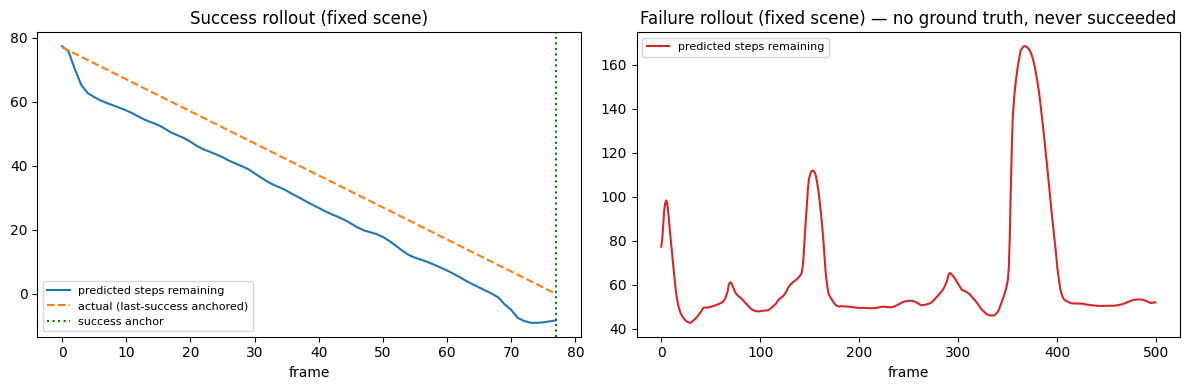

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(success_result["preds"], label="predicted steps remaining")
axes[0].plot(success_result["actual"], "--", label="actual (last-success anchored)")
axes[0].axvline(success_result["last_idx"], color="green", linestyle=":", label="success anchor")
axes[0].set_title("Success rollout (fixed scene)")
axes[0].set_xlabel("frame"); axes[0].legend(fontsize=8)

axes[1].plot(failure_result["preds"], color="tab:red", label="predicted steps remaining")
axes[1].set_title("Failure rollout (fixed scene) — no ground truth, never succeeded")
axes[1].set_xlabel("frame"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**How to read this:**

- Success rollout: predicted (solid) should track actual (dashed) and reach
  ~0 right around the green anchor line.
- Failure rollout: there's no ground truth, but a model that's learned real
  task progress (not just "frames elapsed") should show predictions that
  stay high, flat, or noisy — not a smooth decreasing trend toward 0. If it
  *does* decrease smoothly on an episode that never succeeded, that's the
  shortcut-learning failure mode (keying off elapsed time instead of state)
  to watch for.

**Before moving on:** ranking rho close to 1.0 and a failure curve that does
*not* mimic the success curve's shape means the idea holds up on this one
fixed scene — the thing this whole v6 pass was built to check before
worrying about generalizing across scenes.